In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline

sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [3]:
df = pd.read_csv("titanic.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of Rows: 891
Number of Columns: 12

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.median(numeric_only=True)

,0
PassengerId,446.0000
Survived,0.0000
Pclass,3.0000
Age,28.0000
SibSp,0.0000
Parch,0.0000
Fare,14.4542


In [8]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Values Percentage:")
print(missing_percentage.sort_values(ascending=False))

Missing Values Percentage:
Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


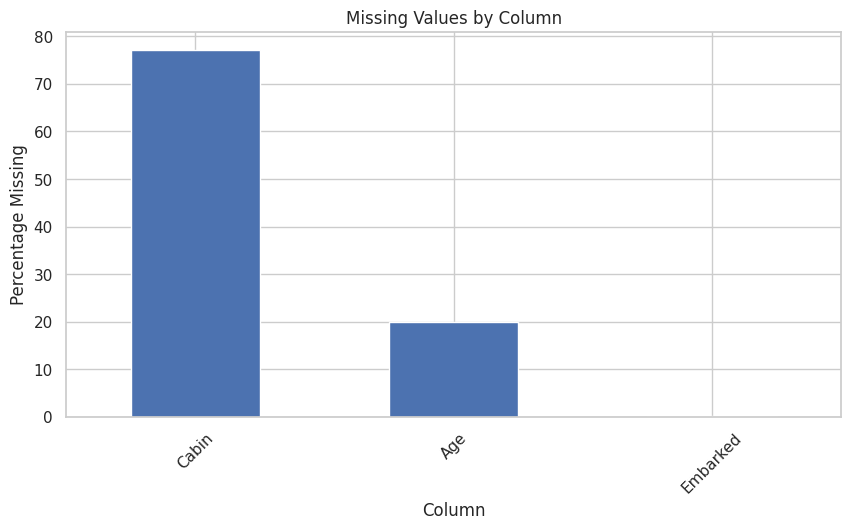

In [10]:
plt.figure(figsize=(10, 5))

missing_percentage[missing_percentage > 0].sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Percentage Missing")
plt.xticks(rotation=45)

plt.show()

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numeric Columns:")
print(numeric_cols.tolist())

Numeric Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


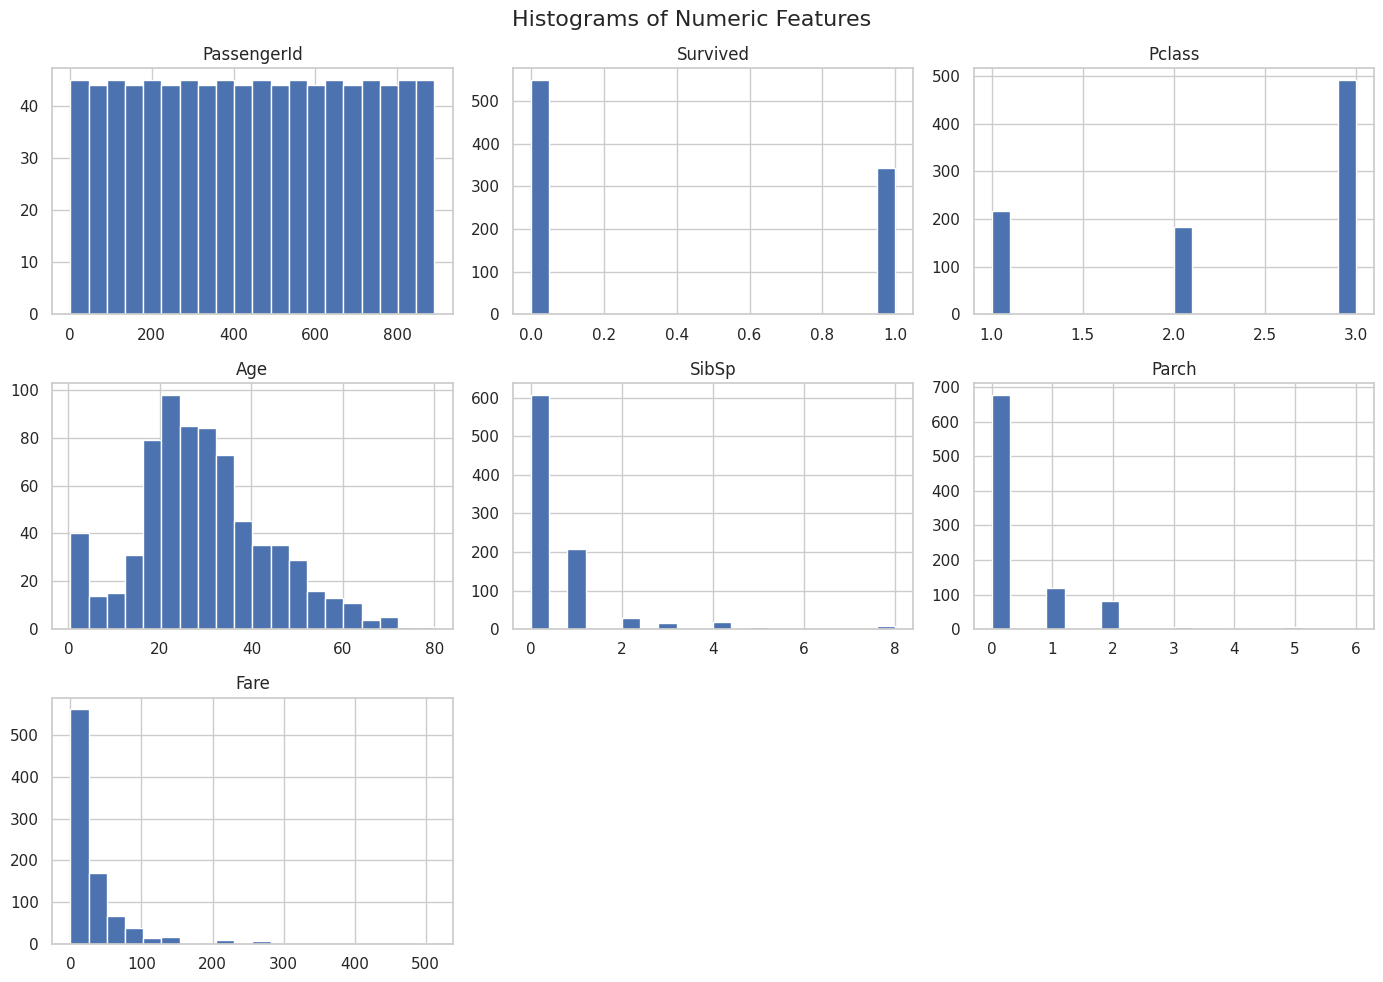

In [12]:
df[numeric_cols].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

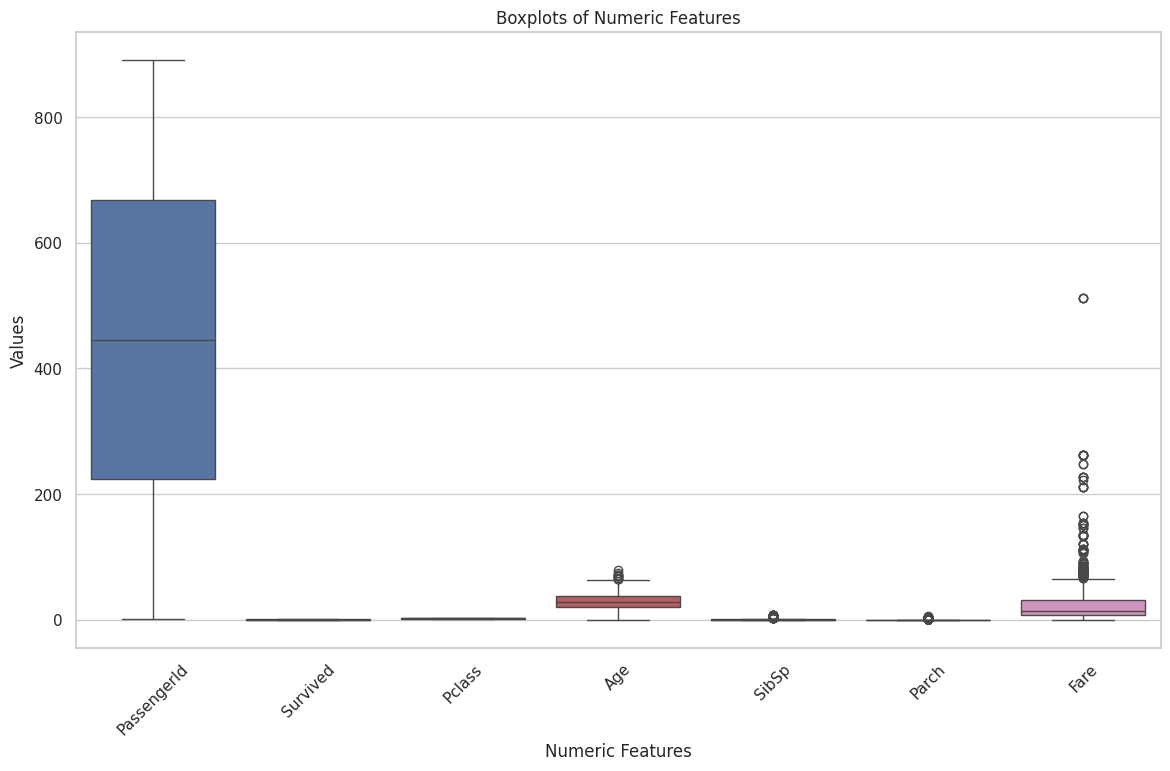

In [13]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df[numeric_cols])

plt.title("Boxplots of Numeric Features")
plt.xlabel("Numeric Features")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.show()

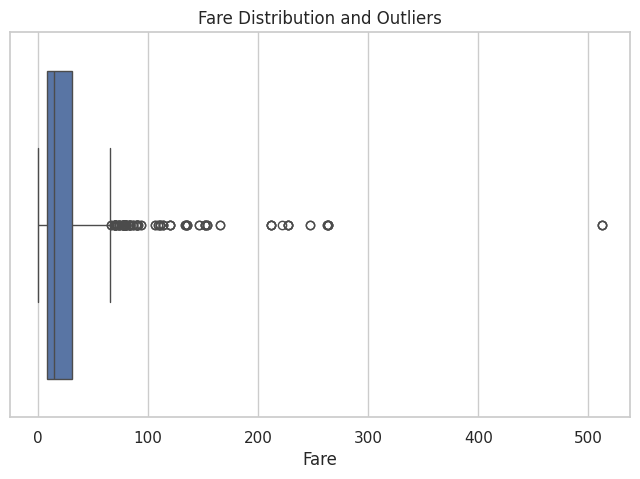

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Distribution and Outliers")
plt.xlabel("Fare")

plt.show()

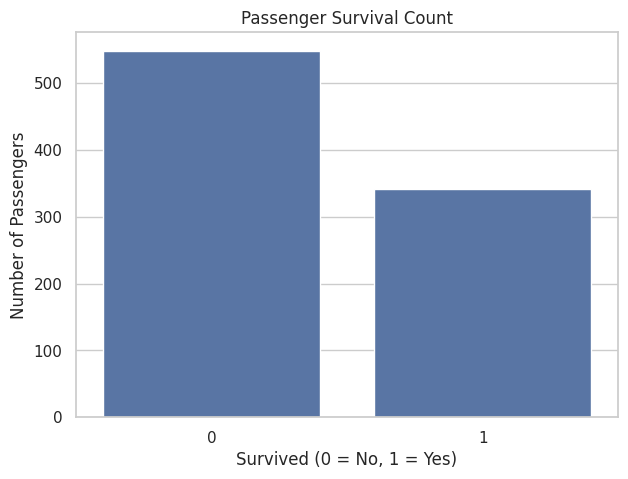

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Survived")

plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [16]:
survival_rate = df["Survived"].value_counts(normalize=True) * 100

print("Survival Percentage:")
print(survival_rate)

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [17]:
print("Passenger Survival Counts:")
print(df["Survived"].value_counts())

Passenger Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64


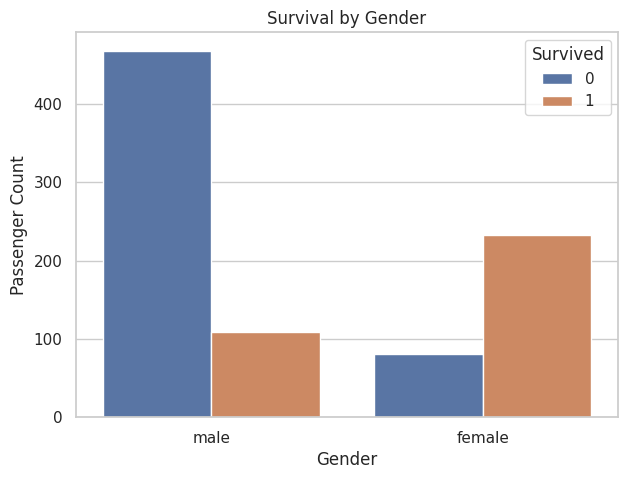

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.show()

In [19]:
gender_survival = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

print("Survival Percentage by Gender:")
print(gender_survival)

Survival Percentage by Gender:
Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


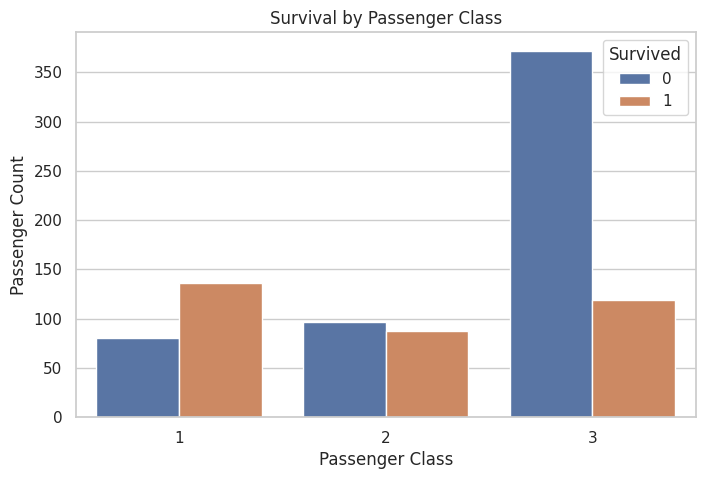

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")

plt.show()

In [21]:
class_survival = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

print("Survival Percentage by Passenger Class:")
print(class_survival)

Survival Percentage by Passenger Class:
Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


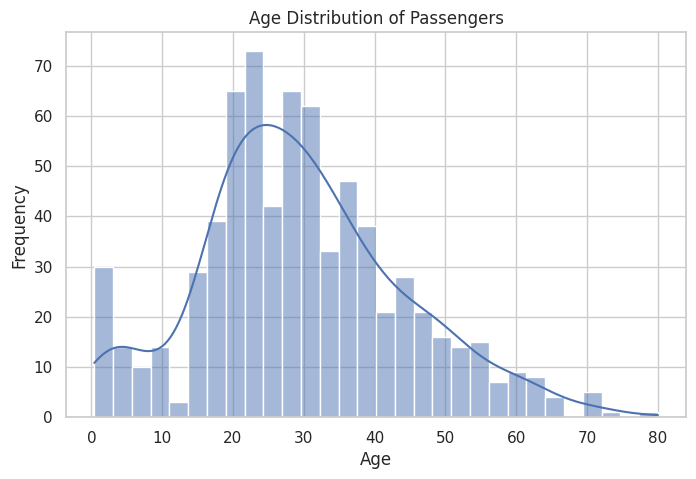

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

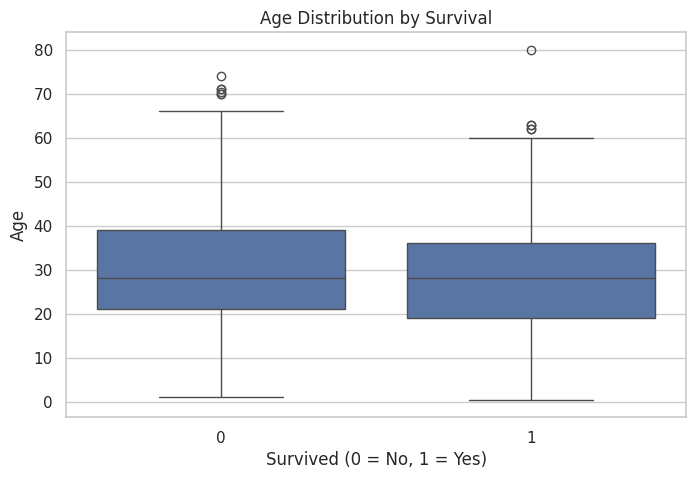

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

In [25]:
correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

correlation_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


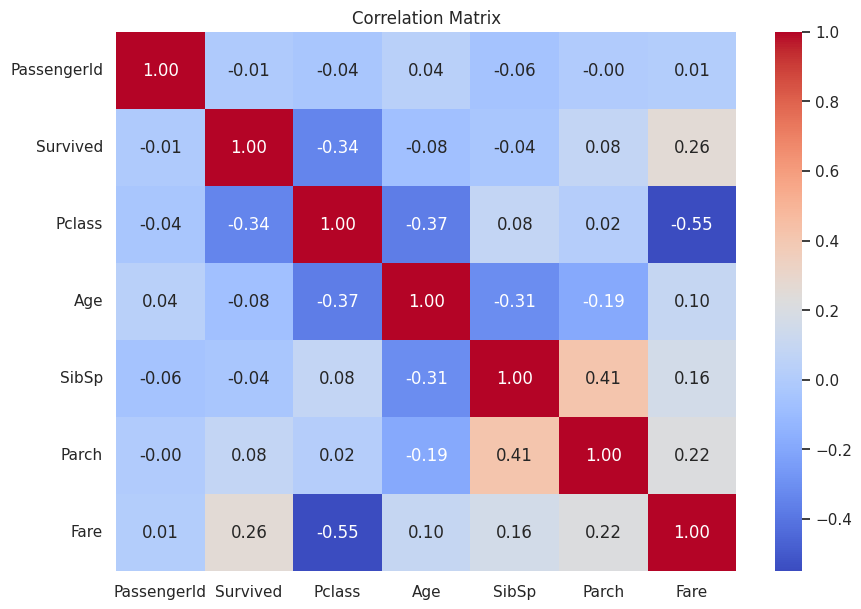

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

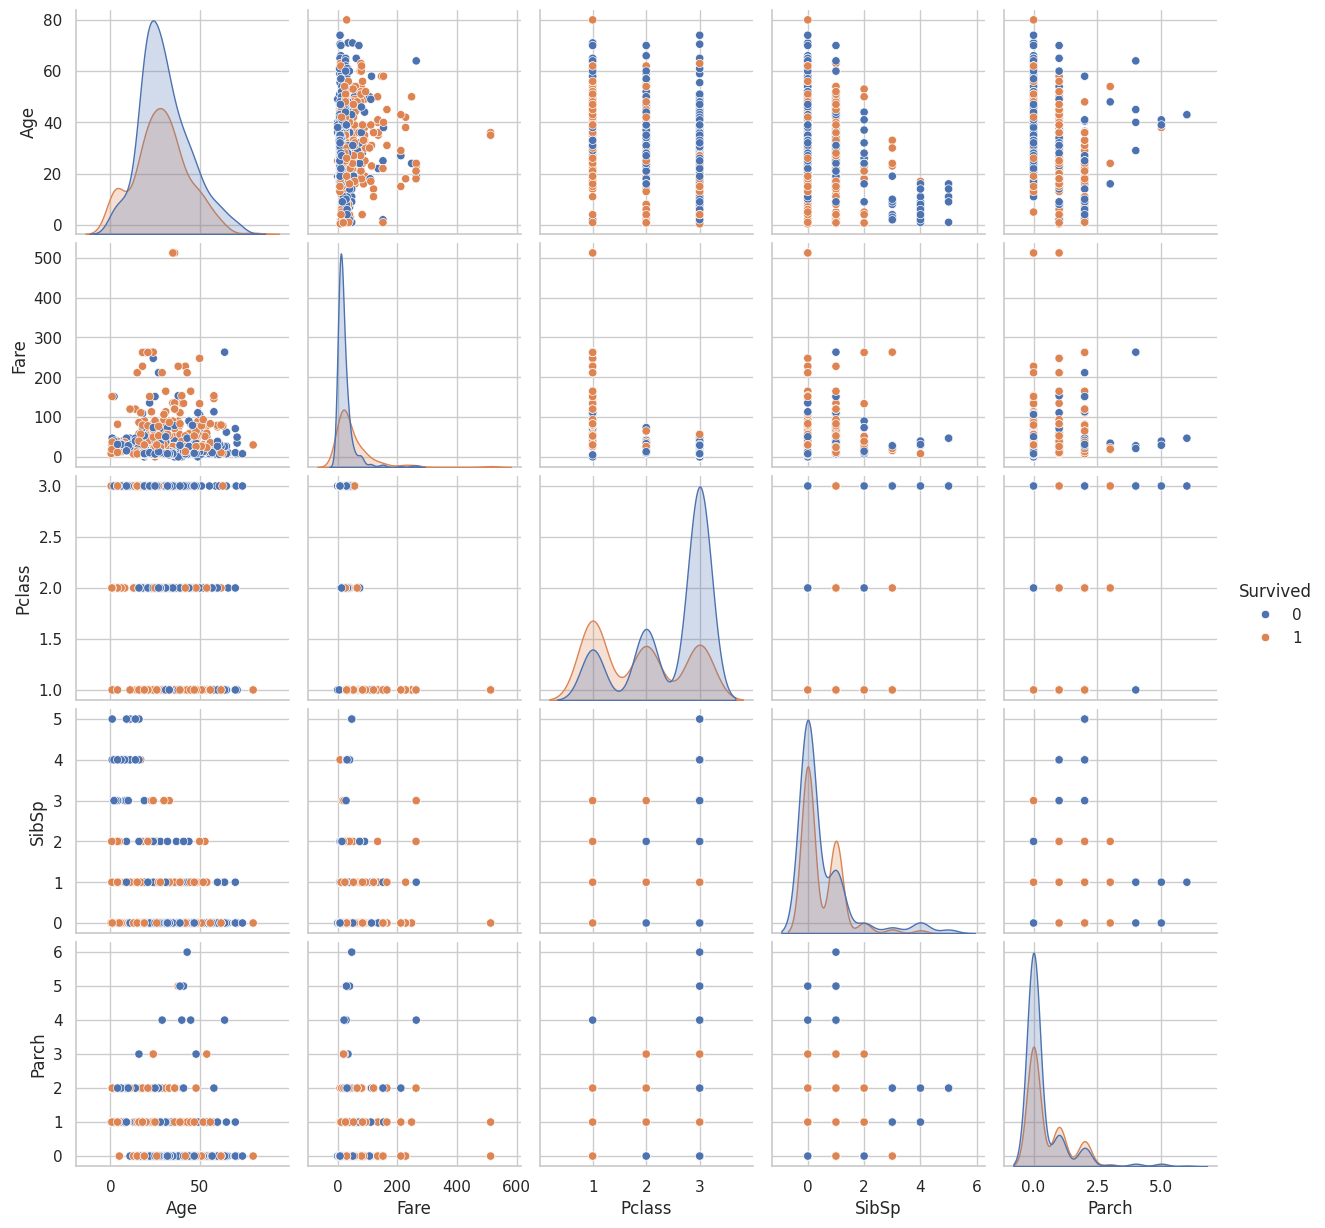

In [27]:
pairplot_cols = [
    "Age",
    "Fare",
    "Pclass",
    "SibSp",
    "Parch",
    "Survived"
]

sns.pairplot(
    df[pairplot_cols].dropna(),
    hue="Survived"
)

plt.show()

In [28]:
fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Survived",
    hover_data=["Sex", "Pclass"],
    title="Age vs Fare by Survival"
)

fig.show()

In [29]:
skewness = df.select_dtypes(include=np.number).skew()

print("Skewness of Numeric Features:")
print(skewness.sort_values(ascending=False))

Skewness of Numeric Features:
Fare           4.787317
SibSp          3.695352
Parch          2.749117
Survived       0.478523
Age            0.389108
PassengerId    0.000000
Pclass        -0.630548
dtype: float64


In [30]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344


In [31]:
outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Number of Fare Outliers:", len(outliers))

Number of Fare Outliers: 116


In [32]:
outliers[["PassengerId", "Pclass", "Sex", "Age", "Fare", "Survived"]].head(10)

,PassengerId,Pclass,Sex,Age,Fare,Survived
1,2,1,female,38.0,71.2833,1
27,28,1,male,19.0,263.0000,0
31,32,1,female,NaN,146.5208,1
34,35,1,male,28.0,82.1708,0
52,53,1,female,49.0,76.7292,1
61,62,1,female,38.0,80.0000,1
62,63,1,male,45.0,83.4750,0
72,73,2,male,21.0,73.5000,0
88,89,1,female,23.0,263.0000,1
102,103,1,male,21.0,77.2875,0


In [33]:
survival_table = pd.pivot_table(
    df,
    values="Survived",
    index="Pclass",
    columns="Sex",
    aggfunc="mean"
)

print("Survival Rate by Passenger Class and Gender:")
print(survival_table * 100)

Survival Rate by Passenger Class and Gender:
Sex        female       male
Pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669


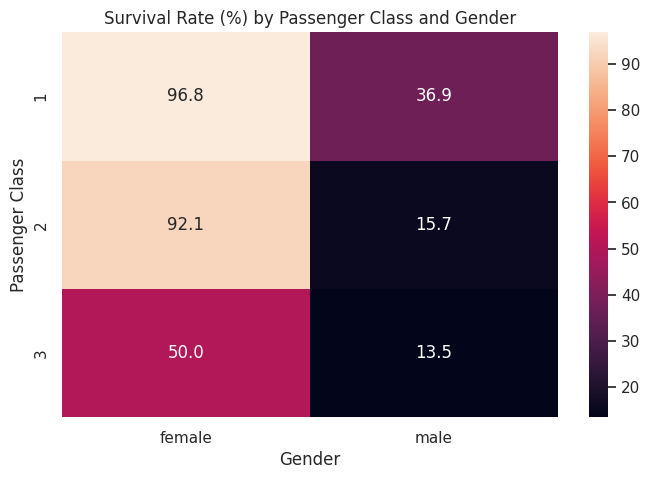

In [34]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    survival_table * 100,
    annot=True,
    fmt=".1f"
)

plt.title("Survival Rate (%) by Passenger Class and Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Class")

plt.show()

## Key EDA Findings

1. The Titanic dataset contains both numerical and categorical features that can be analyzed using descriptive statistics and visualizations.

2. The Fare feature is positively skewed, with a small number of passengers paying significantly higher fares than most passengers.

3. The Fare boxplot identifies several potential high-value outliers. These observations should be investigated rather than automatically removed.

4. Gender shows a strong association with survival in this dataset. Approximately 74.20% of female passengers survived, compared with approximately 18.89% of male passengers.

5. Passenger class also shows an association with survival. The survival rate was approximately 62.96% for first-class passengers, 47.28% for second-class passengers, and 24.24% for third-class passengers.

6. The combined analysis of passenger class and gender shows a clear difference in survival rates. Female passengers had higher survival rates across all passenger classes. First-class females had the highest survival rate at approximately 96.8%, while male survival rates were considerably lower across all classes.

7. The age distribution shows that passengers belonged to a wide range of age groups, with a concentration around younger and middle-aged passengers.

8. The correlation matrix helps identify relationships between numerical variables such as Pclass, Fare, Age, SibSp, Parch, and Survived.

9. Pairplot visualization provides a visual comparison of relationships among multiple numerical features and shows how observations differ based on survival.

10. Features such as Sex, Pclass, and Fare provide useful information when studying passenger survival.

11. Correlation and observed associations do not necessarily imply causation.




## Conclusion

Exploratory Data Analysis was performed on the Titanic dataset using Pandas, NumPy, Matplotlib, Seaborn, and Plotly.

Descriptive statistics were used to understand the numerical features. Histograms and boxplots helped analyze distributions, spread, skewness, and potential outliers. Correlation analysis and pairplots were used to study relationships between numerical features.

The analysis revealed noticeable differences in survival based on gender and passenger class. Female passengers had a substantially higher survival rate than male passengers, while first-class passengers had a higher survival rate than second- and third-class passengers.

The analysis also identified positive skewness and potential outliers in the Fare feature.

Overall, EDA helped transform the raw Titanic dataset into meaningful insights and provided a better understanding of the data before applying machine learning models.


In [36]:
plt.savefig("age_histogram.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

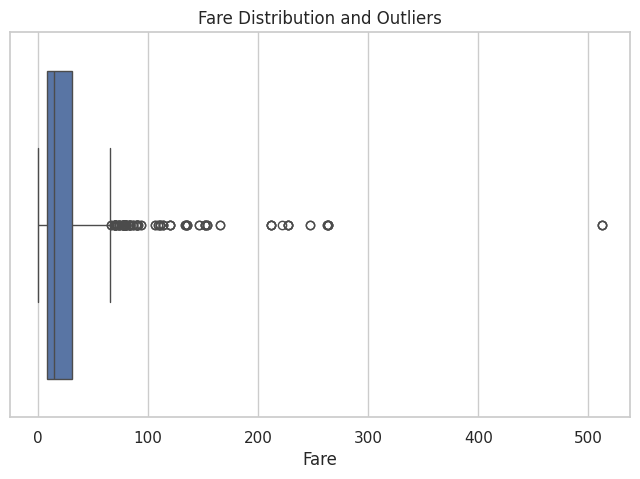

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Distribution and Outliers")

plt.savefig(
    "fare_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()